In [428]:
import jax 
import jax.numpy as jnp
import jax.random as jrandom

jax.config.update('jax_platform_name', 'cpu')

# Set default device to CPU


from functools import partial

import haiku as hk

import matplotlib.pyplot as plt

from probjax.core import rv

import optax

from probjax.nn.helpers import GaussianFourierEmbedding
from probjax.nn.loss_fn import denoising_score_matching_loss
from probjax.distributions.sde import VESDE, VPSDE
from probjax.distributions.transformed_distribution import TransformedDistribution
from probjax.distributions import Normal, Independent, Empirical, Uniform
from probjax.utils.odeint import _odeint

In [599]:
prior = Normal(jnp.zeros((1,)), jnp.ones((1,))) 

In [735]:

# # VESDE 
# T = 1.
# T_min = 1e-5
# sigma_min = 0.01
# sigma_max = 10.

# thetas = prior.sample(jax.random.PRNGKey(0), (10000,))
# p0 = Independent(Empirical(thetas), 1) # Empirical distribution of the data
# sde = VESDE(p0, sigma_min=sigma_min , sigma_max=sigma_max)

# def output_scale_fn(t, x):
#     scale = sde.marginal_stddev(t, jnp.ones_like(x))
#     return (1/scale * x).reshape(x.shape)

# def weight_fn(t):
#     return jnp.clip(sde.diffusion(t, jnp.ones((1,1,1)))**2, 1e-4)

In [736]:

# VPSDE 
T = 1.
T_min = 1e-5
beta_min = 0.01
beta_max = 10.

thetas = prior.sample(jax.random.PRNGKey(0), (10000,))
p0 = Independent(Empirical(thetas), 1) # Empirical distribution of the data
sde = VPSDE(p0, beta_min=beta_min , beta_max=beta_max)

def output_scale_fn(t, x):
    scale = sde.marginal_stddev(t, jnp.ones_like(x))
    return (1/scale * x).reshape(x.shape)

def weight_fn(t):
    return 1-jnp.exp(-0.5 * (beta_max - beta_min) * t**2 - beta_min * t) + 1e-5

In [737]:
# s(theta| x_t, x_t+1)
# x_t R^2, x_t+1 R^2
hidden_dim = 100
activation = jax.nn.relu
num_hidden = 2
layer_norm = True

def score_net(a, theta, x_t0, x_t1):
        context = jnp.concatenate([x_t0, x_t1], axis=-1) 
    
        time_embedding = GaussianFourierEmbedding(hidden_dim)(a[..., None])
        

        
        h1 = hk.Linear(hidden_dim//2)(context)
        h2 = hk.Linear(hidden_dim - hidden_dim//2)(theta)
        
        h = activation(jnp.concatenate([h1, h2], axis=-1) + time_embedding)

        for _ in range(num_hidden - 1):
            h_new = hk.Linear(hidden_dim)(h)
            h_new += time_embedding
            h = activation(h_new)

            if layer_norm:
                h = hk.LayerNorm(axis=-1, create_scale=True, create_offset=True)(h)

        out = hk.Linear(theta.shape[-1])(h)
        #out = output_scale_fn(a, out)
        return out


In [714]:
key = jax.random.PRNGKey(0)
init_fn, model_fn = hk.without_apply_rng(hk.transform(score_net)) # Init function initializes the parameters of the model, model_fn is the actual model function (which takes the parameters as first argument, hence is a "pure function")
params = init_fn(key, jnp.ones(10), thetas[:10], jnp.ones((10, 1)), jnp.ones((10, 1))) # Initialize the parameters of the model

In [715]:
sigma_x0 = 2.
def generate_step(key):
    key1, key2, key3 = jax.random.split(key, 3)
    
    theta_batch = jax.random.normal(key1, (1,))
    x_t = jax.random.normal(key2, (1,))*sigma_x0    
    x_t1 =  x_t + theta_batch + jax.random.normal(key3, (1,)) 
    return theta_batch, x_t, x_t1

def generate_data(key, n):
    keys = jax.random.split(key, (n,))
    return jax.vmap(generate_step)(keys)

In [716]:
theta_batch, x_t0, x_t1 = generate_data(jax.random.PRNGKey(0), 10)

In [717]:
key = jax.random.PRNGKey(0)
init_fn, model_fn = hk.without_apply_rng(hk.transform(score_net)) # Init function initializes the parameters of the model, model_fn is the actual model function (which takes the parameters as first argument, hence is a "pure function")
params = init_fn(key, jnp.ones(10),theta_batch, x_t0, x_t1) # Initialize the parameters of the model

In [718]:


def loss_fn(params, key, batch_size= 256):

    rng_model, rng_time, rng_sample, rng_data, rng_permute_ids, rng_condition = jax.random.split(key, 6)
    
    # Generate data and random times
    times = jax.random.uniform(rng_time, (batch_size, 1), minval=T_min, maxval=1.0)
    theta_batch, x_t0, x_t1 = generate_data(rng_data, batch_size) # n, T_max, 1
    

    # Forward diffusion, do not perturb conditioned data
    loss = denoising_score_matching_loss(params, rng_sample, times, theta_batch, None, model_fn= model_fn, mean_fn=sde.marginal_mean, std_fn = sde.marginal_stddev, weight_fn=weight_fn, x_t0=x_t0, x_t1=x_t1, axis=-1)
    
    return loss


In [719]:
@partial(jax.pmap, axis_name="num_devices")
def update(params, rng, opt_state):
    loss, grads = jax.value_and_grad(loss_fn)(params, rng)
    
    loss = jax.lax.pmean(loss, axis_name="num_devices")
    grads = jax.lax.pmean(grads, axis_name="num_devices")
    
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    params = optax.apply_updates(params, updates)
    return loss, params, opt_state

In [720]:
#schedule = optax.linear_schedule(1e-3, 0, 500*10, 500*10)
optimizer = optax.chain(optax.adaptive_grad_clip(10.), optax.adam(5e-4))
opt_state = optimizer.init(params)

In [721]:
n_devices = jax.local_device_count()
replicated_params = jax.tree_map(lambda x: jnp.array([x] * n_devices), params)
replicated_opt_state = jax.tree_map(lambda x: jnp.array([x] * n_devices), opt_state)

In [722]:
key = jrandom.PRNGKey(0)

In [723]:
for _ in range(10):
    l = 0
    for i in range(100):
        key, subkey = jrandom.split(key)
        loss, replicated_params, replicated_opt_state = update(replicated_params, jax.random.split(subkey, (n_devices,)), replicated_opt_state)
        l += loss[0] / 100
    print(l)

17.10113
12.000495
11.526988
11.658043
11.680175


KeyboardInterrupt: 

In [724]:
params = jax.tree_map(lambda x: x[0], replicated_params)

In [730]:
t = jnp.linspace(-4,4, 1000)
t = t.reshape(-1, 1)    
s = model_fn(params, jnp.array([0.0001]*1000), t, jnp.zeros((1000,1)),  jnp.ones((1000,1)))

In [731]:
true_score = - 2 *t + (x_o[1] - x_o[0])

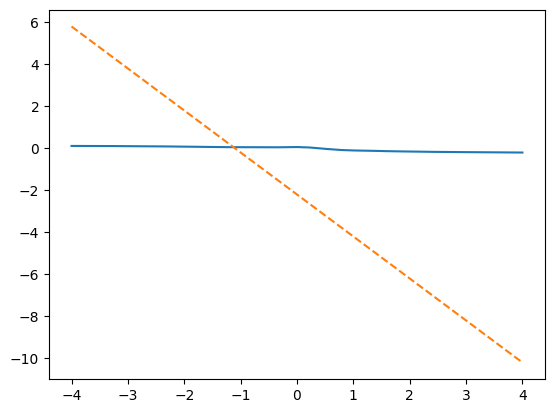

In [734]:
plt.plot(t, s)
plt.plot(t, true_score, "--")

In [566]:
theta_o = jnp.array([-2])

x_0 = jnp.array([0.])
xs = [x_0]
for i in range(1):
    x_1 = x_0 + theta_o + jax.random.normal(jrandom.PRNGKey(i+2), (1,))
    x_0 = x_1
    xs.append(x_1)
    
x_o = jnp.array(xs)[:,0]

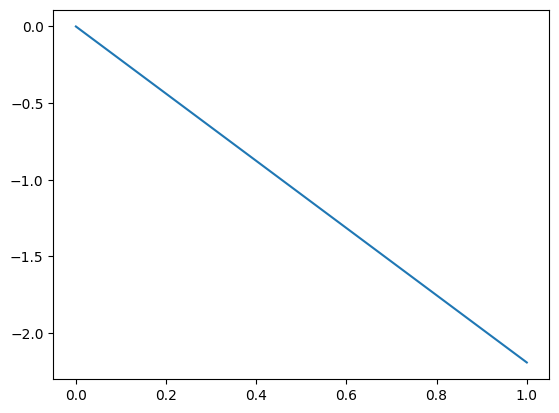

In [567]:
plt.plot(x_o, label="true")

In [568]:
theta = theta_o
t = jnp.array([0.1])

In [569]:
x_past = x_o[:-1, None]
x_future = x_o[1:,None]

In [570]:
jax.devices()

[CpuDevice(id=0)]

In [571]:
from functools import partial
from probjax.utils.sdeint import sdeint


# Reverse SDE drift
def drift_backward(t, theta, x_o):
    #x1, x2 = jnp.split(x_o, 2)
    
    x_past = x_o[:-1, None]
    x_future = x_o[1:,None]
    
    theta_batch = jnp.broadcast_to(theta, (x_past.shape[0], theta.shape[-1]))
    increment_scores = model_fn(params, t, theta_batch, x_past, x_future)
    N = increment_scores.shape[0]
    prior_score = (1-t)*jax.grad(lambda x: prior.log_prob(x).sum())(theta) 
    likelihood_score =  jnp.sum(increment_scores - prior_score, axis=0)
    score = likelihood_score + prior_score

    score = score.reshape(theta.shape)

    f =  sde.drift(t,theta) - sde.diffusion(t,theta)**2 * score
    
    return f

# Reverse SDE diffusion
def diffusion_backward(t,theta):
    #t = T - t
    b =  sde.diffusion(t,theta) 
    return b

In [572]:

end_std = jnp.squeeze(sde.marginal_stddev(jnp.ones(1)))
end_mean = jnp.squeeze(sde.marginal_mean(jnp.ones(1)))

def sample_fn(key, shape,x_o, time_steps=200):
    key1, key2 = jrandom.split(key, 2)
    # Sample from noise distribution at time 1
    x_T = jax.random.normal(key1, shape + (1,)) * end_std + end_mean
    
    # Sove backward sde
    keys = jrandom.split(key2, shape)
    ys = jax.vmap(lambda *args: sdeint(*args, noise_type="diagonal"), in_axes= (0, None, None, 0, None), out_axes=0)(keys, lambda t, x: drift_backward(t, x, x_o=x_o), lambda t, x: diffusion_backward(t, x), x_T, jnp.linspace(1.,T_min, time_steps))
    return ys


In [554]:
x_o

Array([ 0.   , -2.206], dtype=float32)

In [573]:
def true_posterior(x_o):
    
    x_past = x_o[:-1, None]
    x_future = x_o[1:,None]
    
    mean_posterior = (x_future- x_past)/2
    std_posterior = 1/jnp.sqrt(2)
    return Normal(mean_posterior, std_posterior)

In [574]:
samples = sample_fn(jrandom.PRNGKey(0), (1000,), x_o)

In [575]:
l = jnp.linspace(-5, 5, 100)
#Z = jnp.exp(true_posterior(x_o).log_prob(l[:,None]).sum(-1))

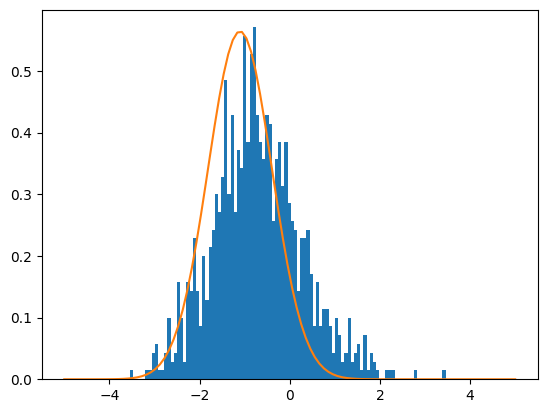

In [576]:
plt.hist(samples[:, -1,0], density=True, bins = 100)
plt.plot(l,Z)

In [ ]:
samples[:,-10, 0]

Array([-1.531e+16,  2.372e+16, -1.183e+16, -4.050e+14, -6.181e+15,
        7.594e+16,  4.265e+16,  1.044e+16,  5.462e+16,  2.518e+15,
       -1.725e+15,  9.949e+15,  4.126e+16,  9.818e+14,  1.624e+16,
       -6.882e+15,  1.128e+16,  3.780e+16,  4.895e+15,  1.155e+15,
        1.867e+16,  5.512e+15, -1.012e+16,  3.446e+16,  1.492e+16,
        1.248e+15,  6.822e+15, -2.879e+16,  6.008e+16,  1.334e+16,
       -2.867e+16, -1.461e+16, -8.456e+14, -3.785e+16,  1.564e+16,
       -1.680e+15, -2.551e+16, -1.870e+16, -1.745e+16, -1.850e+15,
        2.461e+15,  3.029e+16,  2.402e+16,  3.905e+14, -3.163e+16,
        3.075e+16,  8.877e+15,  1.095e+15, -3.074e+15,  1.439e+16,
        8.470e+14,  3.102e+16,  6.757e+16, -4.376e+15,  4.587e+16,
       -8.910e+15,  1.203e+16,  2.553e+16,  2.372e+16,  2.504e+16,
        8.436e+15, -1.125e+16,  3.987e+16,  4.140e+16,  9.697e+15,
        3.647e+16, -3.222e+16, -1.603e+16, -4.199e+15,  4.473e+15,
       -5.896e+15, -2.977e+16,  2.189e+16, -2.912e+16, -2.339e